# Étape 2 — EDA : Exploration et analyse des dépendances

## Objectif

L'objectif de cette étape est de comprendre les facteurs associés au temps total de livraison `Time_taken(min)` avant la phase de modélisation.

Cette analyse couvre :

- la structure et la qualité du jeu de données nettoyé ;
- les statistiques descriptives des variables numériques ;
- les fréquences des variables catégorielles, y compris `Vehicle_condition` (désormais conservée) ;
- la distribution de la variable cible ;
- la relation entre la cible et chaque variable explicative ;
- les corrélations entre variables numériques ;
- l'identification des variables les plus liées au temps de livraison ;
- les décisions qui serviront de base au feature engineering.

Le nettoyage ne crée aucune variable dérivée : les coordonnées GPS et les colonnes de date/heure sont explorées ici sous leur forme brute. Toutes les transformations (`Distance_km`, `Order_Hour`, `Pickup_Hour`, `Order_DayOfWeek`, `Order_Month`, `Order_Day`, `Is_Weekend`, `Preparation_Time_min`) auront lieu dans le notebook de feature engineering.

**Principe important :** l'EDA sert à comprendre les données. Elle ne doit pas utiliser d'informations futures indisponibles au moment de la commande et ne doit pas supprimer automatiquement des observations uniquement parce qu'elles sont atypiques.

In [8]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:.3f}")

sns.set_theme(style="whitegrid")

TARGET = "Time_taken(min)"
PROJECT_ROOT = Path(f"{Path.cwd()}/eda.ipynb").resolve().parents[1]
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "food_delivery_cleaned.csv"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures" / "eda"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(name):
    path = FIGURES_DIR / name
    plt.savefig(path, dpi=150, bbox_inches="tight")
    return path

## 1. Chargement du jeu de données nettoyé

Le notebook EDA travaille sur le fichier produit par l'étape de nettoyage.

Rappel des décisions de nettoyage :

- `ID` et `Delivery_person_ID` sont supprimées (identifiants).
- `Vehicle_condition` est conservée, traitée comme variable catégorielle nominale (pas de hiérarchie supposée entre 0 et 3).
- `Time_Order_picked` est conservée telle quelle.
- `Time_Orderd` ne contient plus de valeurs manquantes : les valeurs absentes ont été imputées en interne lors du nettoyage, à partir de `Time_Order_picked` et d'un temps de préparation médian calculé temporairement à cette seule fin.

Aucun indicateur de valeur imputée n'est conservé, et aucune variable dérivée (temps de préparation, distance, heure extraite, etc.) n'est créée à ce stade : ces transformations relèvent uniquement du notebook de feature engineering.

In [9]:
df = pd.read_csv(DATA_PATH)

df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce")
df["Time_Orderd"] = pd.to_datetime(df["Time_Orderd"], errors="coerce")
df["Time_Order_picked"] = pd.to_datetime(df["Time_Order_picked"], errors="coerce")

df["Vehicle_condition"] = df["Vehicle_condition"].astype("category")

print(f"Shape: {df.shape}")
display(df.head())

Shape: (41953, 18)


,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Vehicle_condition,Weatherconditions,Road_traffic_density,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,37.000,4.900,22.745,75.892,22.765,75.912,2022-03-19,1900-01-01 11:30:00,1900-01-01 11:45:00,2,Sunny,High,Snack,motorcycle,0.000,No,Urban,24
1,34.000,4.500,12.913,77.683,13.043,77.813,2022-03-25,1900-01-01 19:45:00,1900-01-01 19:50:00,2,Stormy,Jam,Snack,scooter,1.000,No,Metropolitian,33
2,23.000,4.400,12.914,77.678,12.924,77.688,2022-03-19,1900-01-01 08:30:00,1900-01-01 08:45:00,0,Sandstorms,Low,Drinks,motorcycle,1.000,No,Urban,26
3,38.000,4.700,11.004,76.976,11.054,77.026,2022-04-05,1900-01-01 18:00:00,1900-01-01 18:10:00,0,Sunny,Medium,Buffet,motorcycle,1.000,No,Metropolitian,21
4,32.000,4.600,12.973,80.250,13.013,80.290,2022-03-26,1900-01-01 13:30:00,1900-01-01 13:45:00,1,Cloudy,High,Snack,scooter,1.000,No,Metropolitian,30


## 2. Contrôle général de la structure

Cette étape vérifie les dimensions, les types, les valeurs manquantes et les doublons.

Les résultats doivent confirmer que le nettoyage précédent a bien été appliqué.

In [10]:
print("Dimensions :", df.shape)
print("\nColonnes :")
print(df.columns.tolist())

print("\nTypes :")
display(df.dtypes.to_frame("dtype"))

print("\nValeurs manquantes :")
display(df.isna().sum().to_frame("missing"))

print("\nDoublons complets :", df.duplicated().sum())

print("\nStatistiques de la cible :")
display(df[TARGET].describe())

print("\nValeurs manquantes restantes pour Time_Orderd :")
print(df["Time_Orderd"].isna().sum())

Dimensions : (41953, 18)

Colonnes :
['Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Order_Date', 'Time_Orderd', 'Time_Order_picked', 'Vehicle_condition', 'Weatherconditions', 'Road_traffic_density', 'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)']

Types :


,dtype
Delivery_person_Age,float64
Delivery_person_Ratings,float64
Restaurant_latitude,float64
Restaurant_longitude,float64
Delivery_location_latitude,float64
Delivery_location_longitude,float64
Order_Date,datetime64[us]
Time_Orderd,datetime64[us]
Time_Order_picked,datetime64[us]
Vehicle_condition,category



Valeurs manquantes :


,missing
Delivery_person_Age,0
Delivery_person_Ratings,0
Restaurant_latitude,0
Restaurant_longitude,0
Delivery_location_latitude,0
Delivery_location_longitude,0
Order_Date,0
Time_Orderd,0
Time_Order_picked,0
Vehicle_condition,0



Doublons complets : 0

Statistiques de la cible :


count   41953.000
mean       26.312
std         9.381
min        10.000
25%        19.000
50%        26.000
75%        32.000
max        54.000
Name: Time_taken(min), dtype: float64


Valeurs manquantes restantes pour Time_Orderd :
0


## 3. Analyse descriptive — variables numériques

Pour les variables numériques, on étudie au minimum :

- la moyenne ;
- la médiane ;
- l'écart-type ;
- les minimum et maximum ;
- les quartiles.

La médiane est particulièrement utile lorsque la distribution n'est pas parfaitement symétrique.

In [11]:
numeric_columns = df.select_dtypes(include=["number"]).columns.tolist()

numeric_descriptive = df[numeric_columns].agg(
    ["count", "mean", "median", "std", "min", "max"]
).T

display(numeric_descriptive)

,count,mean,median,std,min,max
Delivery_person_Age,41953.000,29.574,30.000,5.654,20.000,40.000
Delivery_person_Ratings,41953.000,4.634,4.700,0.326,1.000,5.000
Restaurant_latitude,41953.000,18.911,19.066,5.468,9.957,30.914
Restaurant_longitude,41953.000,76.923,76.618,3.503,72.769,88.433
Delivery_location_latitude,41953.000,18.975,19.123,5.470,9.967,31.054
Delivery_location_longitude,41953.000,76.987,76.664,3.503,72.779,88.563
multiple_deliveries,41953.000,0.751,1.000,0.567,0.000,3.000
Time_taken(min),41953.000,26.312,26.000,9.381,10.000,54.000


## 4. Analyse descriptive — variables catégorielles

Pour chaque variable catégorielle, on mesure les fréquences absolues et relatives.

Cette étape permet notamment d'identifier :

- les catégories dominantes ;
- les classes rares ;
- les déséquilibres de représentation qui devront être pris en compte lors de l'encodage.

`Vehicle_condition` apparaît désormais dans cette section : elle est traitée comme catégorielle nominale plutôt que comme une échelle numérique ordonnée, conformément à la décision de nettoyage.

In [12]:
categorical_columns = df.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

categorical_columns = [
    column for column in categorical_columns
    if column != TARGET
]

for column in categorical_columns:
    print(f"\n### {column}")
    frequency = (
        df[column]
        .value_counts(dropna=False)
        .rename_axis(column)
        .to_frame("count")
    )
    frequency["percentage"] = (
        frequency["count"] / len(df) * 100
    )
    display(frequency)


### Vehicle_condition


,count,percentage
Vehicle_condition,,
1,13851,33.016
0,13815,32.930
2,13806,32.908
3,481,1.147



### Weatherconditions


,count,percentage
Weatherconditions,,
Fog,7581,18.070
Stormy,6974,16.623
Cloudy,6932,16.523
Sandstorms,6906,16.461
Windy,6832,16.285
Sunny,6728,16.037



### Road_traffic_density


...

,count,percentage
Type_of_vehicle,,
motorcycle,24396,58.151
scooter,14029,33.440
electric_scooter,3468,8.266
bicycle,60,0.143



### Festival


,count,percentage
Festival,,
No,41131,98.041
Yes,822,1.959



### City


,count,percentage
City,,
Metropolitian,31411,74.872
Urban,9279,22.118
Unknown,1114,2.655
Semi-Urban,149,0.355


## 5. Distribution de `Time_taken(min)`

La variable cible doit être étudiée avant toute modélisation.

Nous utilisons :

- un histogramme avec densité ;
- un boxplot ;
- des statistiques de position et de dispersion.

Les valeurs élevées ne seront pas supprimées automatiquement : l'objectif métier est justement de prédire les livraisons longues.

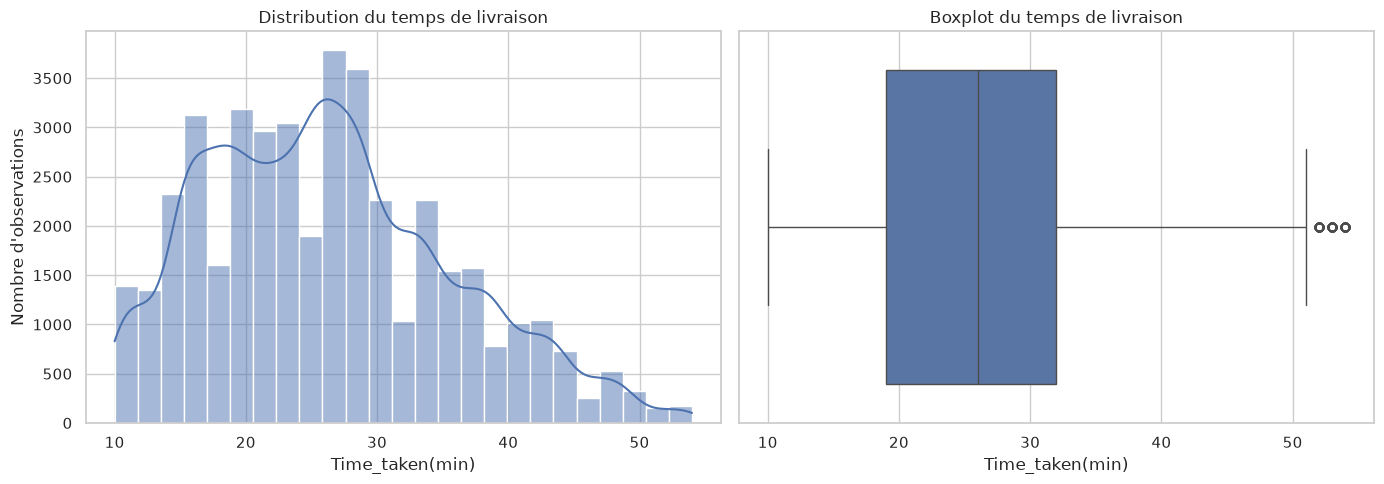

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    df[TARGET],
    kde=True,
    bins=25,
    ax=axes[0],
)
axes[0].set_title("Distribution du temps de livraison")
axes[0].set_xlabel("Time_taken(min)")
axes[0].set_ylabel("Nombre d'observations")

sns.boxplot(
    x=df[TARGET],
    ax=axes[1],
)
axes[1].set_title("Boxplot du temps de livraison")
axes[1].set_xlabel("Time_taken(min)")

plt.tight_layout()
save_fig("target_distribution.png")
plt.show()

## 6. Relation entre la cible et les variables numériques

Pour chaque variable numérique, on étudie :

- la relation visuelle avec la cible ;
- la corrélation de Pearson ;
- la corrélation de Spearman.

**Pearson** mesure une relation linéaire.

**Spearman** mesure une relation monotone et est souvent plus robuste lorsque la relation n'est pas parfaitement linéaire.

Les coordonnées GPS seront analysées comme variables explicatives brutes. La distance réelle entre le restaurant et le client sera créée ensuite dans le notebook de feature engineering.

,pearson,spearman,abs_spearman
multiple_deliveries,0.378,0.330,0.330
Delivery_person_Age,0.295,0.309,0.309
Delivery_person_Ratings,-0.335,-0.287,0.287
Delivery_location_latitude,0.014,0.029,0.029
Delivery_location_longitude,0.010,0.027,0.027
Restaurant_latitude,0.012,0.012,0.012
Restaurant_longitude,0.007,0.005,0.005


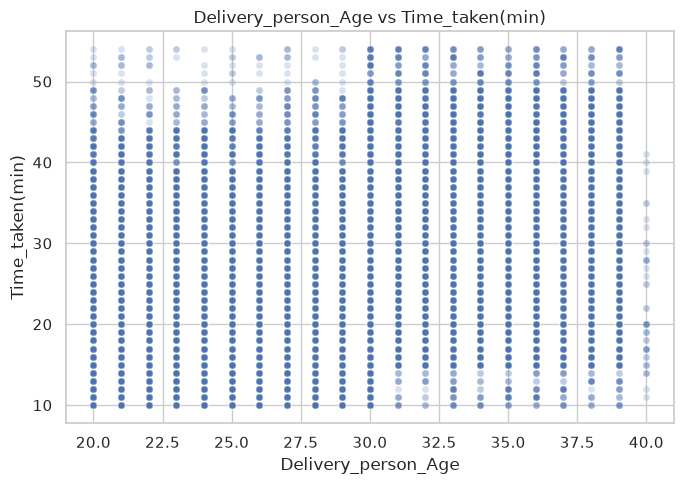

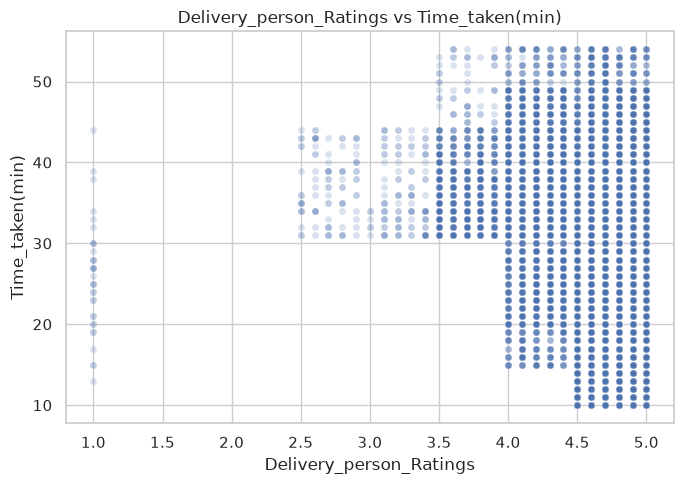

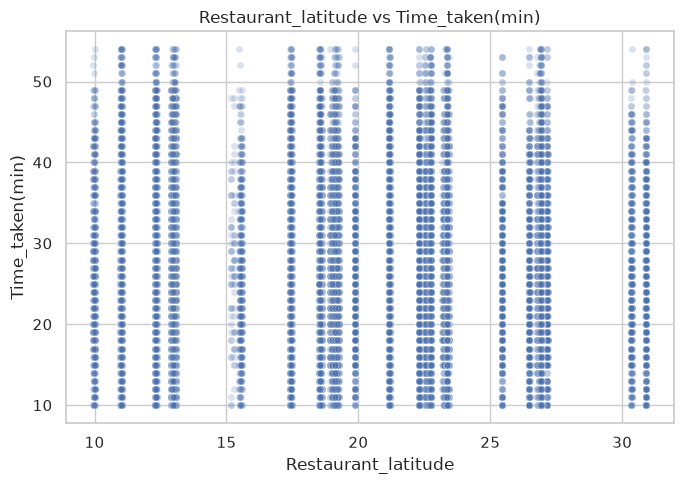

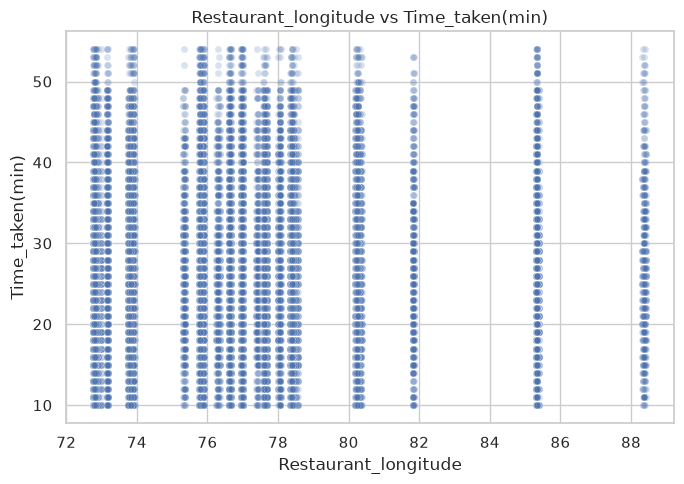

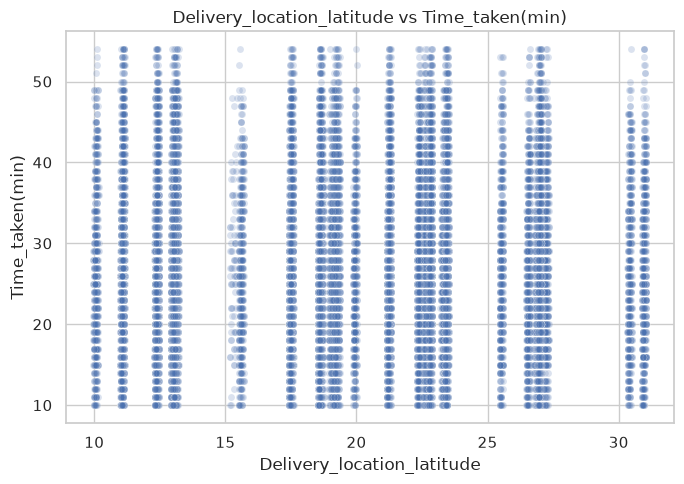

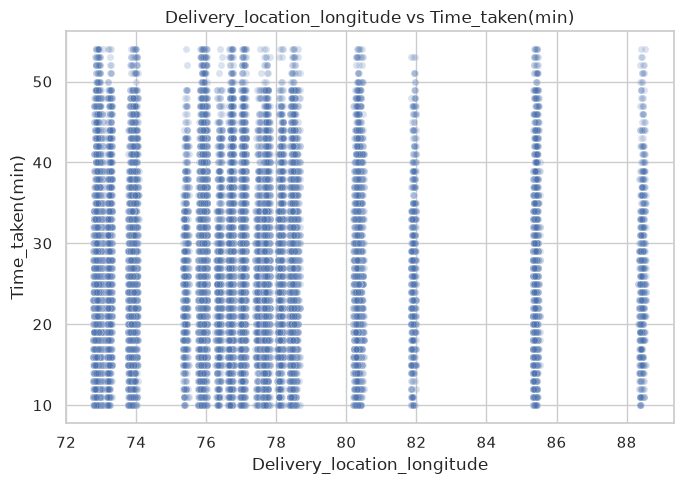

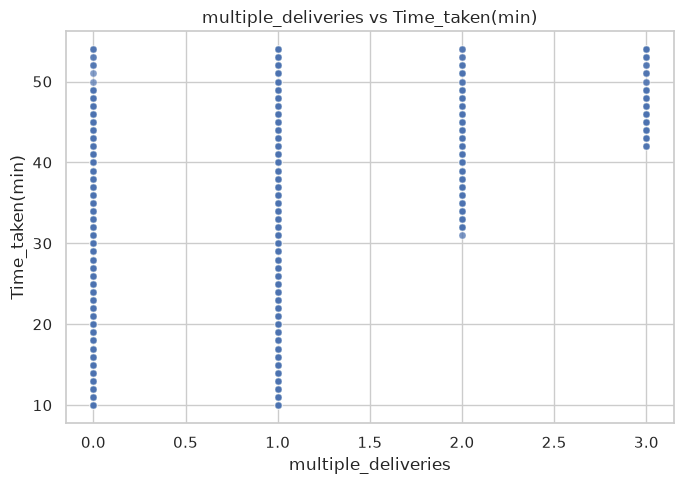

In [14]:
numeric_predictors = [
    column for column in numeric_columns
    if column != TARGET
]

pearson = df[numeric_predictors + [TARGET]].corr(method="pearson")[TARGET].drop(TARGET)
spearman = df[numeric_predictors + [TARGET]].corr(method="spearman")[TARGET].drop(TARGET)

numeric_relationships = pd.DataFrame({
    "pearson": pearson,
    "spearman": spearman,
    "abs_spearman": spearman.abs(),
}).sort_values("abs_spearman", ascending=False)

display(numeric_relationships)

for column in numeric_predictors:
    plt.figure(figsize=(7, 5))
    sns.scatterplot(
        data=df,
        x=column,
        y=TARGET,
        alpha=0.20,
        s=25,
    )
    plt.title(f"{column} vs {TARGET}")
    plt.xlabel(column)
    plt.ylabel(TARGET)
    plt.tight_layout()
    save_fig(f"target_vs_{column}.png")
    plt.show()

## 7. Analyse temporelle exploratoire

`Order_Date` et `Time_Orderd` sont des variables temporelles.

Nous ne les envoyons pas directement à un modèle de régression. Elles seront transformées dans le notebook de feature engineering.

Pour l'EDA, nous créons temporairement des variables d'analyse :

- heure de commande ;
- jour de la semaine ;
- mois ;
- week-end.

Ces colonnes sont uniquement destinées à l'exploration dans ce notebook.

`Order_Hour` ne présente plus de valeurs manquantes, `Time_Orderd` ayant été entièrement imputée lors du nettoyage. `Pickup_Hour`, dérivée de `Time_Order_picked`, est ajoutée à titre exploratoire pour comparer l'heure de commande et l'heure de prise en charge.

In [15]:
eda_time = df.copy()

eda_time["Order_Hour"] = eda_time["Time_Orderd"].dt.hour
eda_time["Order_DayOfWeek"] = eda_time["Order_Date"].dt.dayofweek
eda_time["Order_Month"] = eda_time["Order_Date"].dt.month
eda_time["Is_Weekend"] = eda_time["Order_DayOfWeek"].isin([5, 6])

day_names = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday",
}

eda_time["Day_Name"] = eda_time["Order_DayOfWeek"].map(day_names)

temporal_hour_summary = (
    eda_time.groupby("Order_Hour", dropna=False)[TARGET]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
)

temporal_day_summary = (
    eda_time.groupby(
        "Day_Name",
        dropna=False,
    )[TARGET]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
)

temporal_month_summary = (
    eda_time.groupby(
        "Order_Month",
        dropna=False,
    )[TARGET]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
)

display(temporal_hour_summary)
display(temporal_day_summary)
display(temporal_month_summary)

,Order_Hour,count,mean,median,std
0,0,415,22.229,21.000,7.251
1,8,1749,19.623,19.000,5.613
2,9,1878,19.481,19.000,5.524
3,10,1887,19.484,19.000,5.532
4,11,1865,26.478,27.000,8.317
5,12,860,26.877,27.000,8.736
6,13,748,27.766,27.000,8.686
7,14,756,27.308,27.000,8.238
8,15,831,23.237,23.000,6.949
9,16,676,23.055,24.000,6.895


,Day_Name,count,mean,median,std
0,Friday,6408,26.823,26.000,9.516
1,Monday,5722,26.227,25.000,9.326
2,Saturday,5810,25.973,25.000,9.284
3,Sunday,5736,26.457,25.500,9.390
4,Thursday,5841,25.284,25.000,9.013
5,Tuesday,5884,25.435,25.000,9.089
6,Wednesday,6552,27.762,27.000,9.730


,Order_Month,count,mean,median,std
0,2,6016,26.517,26.000,9.392
1,3,29972,26.305,26.000,9.399
2,4,5965,26.136,25.000,9.277


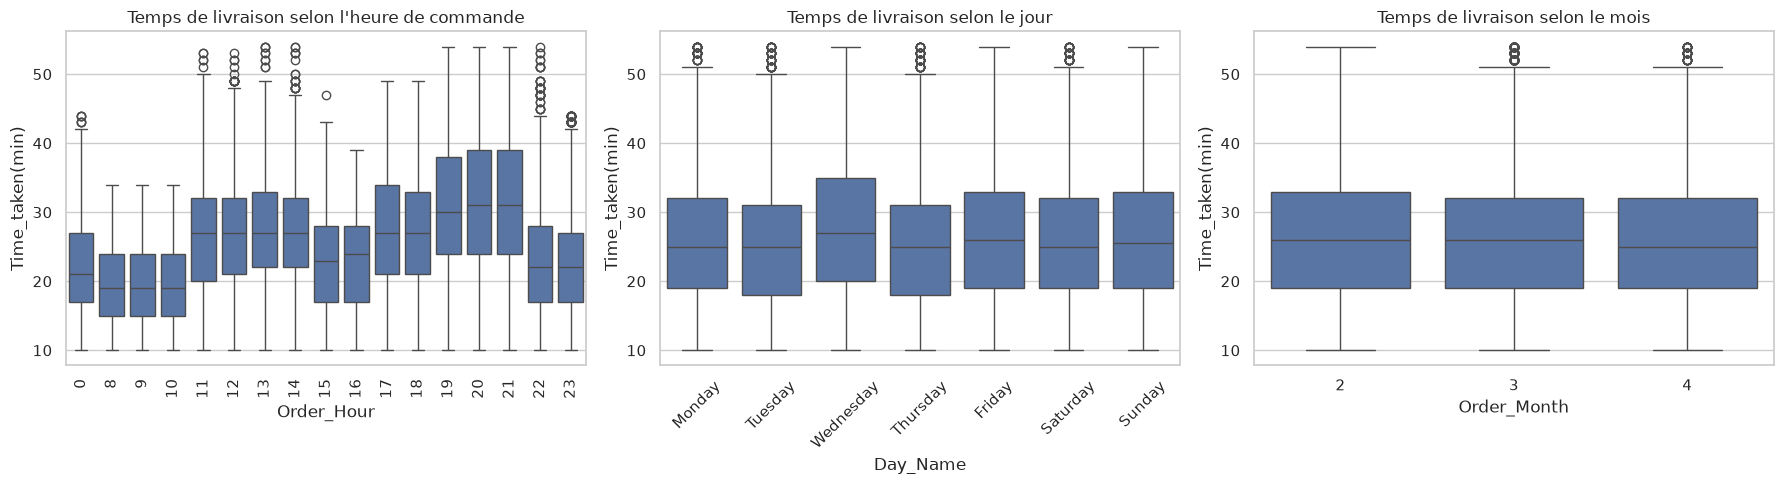

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(
    data=eda_time,
    x="Order_Hour",
    y=TARGET,
    ax=axes[0],
)
axes[0].set_title("Temps de livraison selon l'heure de commande")
axes[0].tick_params(axis="x", rotation=90)

sns.boxplot(
    data=eda_time,
    x="Day_Name",
    y=TARGET,
    order=list(day_names.values()),
    ax=axes[1],
)
axes[1].set_title("Temps de livraison selon le jour")
axes[1].tick_params(axis="x", rotation=45)

sns.boxplot(
    data=eda_time,
    x="Order_Month",
    y=TARGET,
    ax=axes[2],
)
axes[2].set_title("Temps de livraison selon le mois")

plt.tight_layout()
save_fig("target_temporal_relationships.png")
plt.show()

## 8. Relation entre la cible et chaque variable catégorielle

Pour les variables catégorielles, on compare :

- le nombre d'observations par modalité ;
- la moyenne du temps de livraison ;
- la médiane ;
- la dispersion ;
- la distribution du temps de livraison par catégorie.

Nous calculons également l'**eta-squared** comme mesure descriptive de l'association entre une variable catégorielle et une cible numérique.

Une grande valeur d'eta-squared indique que les différences entre les groupes expliquent une part plus importante de la variance de la cible. Il ne s'agit pas d'une preuve de causalité.

`Vehicle_condition` apparaît désormais dans ce classement, aux côtés des autres variables catégorielles, conformément à sa nouvelle décision de conservation.

,feature,eta_squared,n_unique
0,Road_traffic_density,0.179,4
1,Festival,0.083,2
2,Vehicle_condition,0.080,4
3,City,0.063,4
4,Weatherconditions,0.062,6
5,Type_of_vehicle,0.027,4
6,Type_of_order,0.000,4



### Vehicle_condition


,count,mean,median,std
Vehicle_condition,,,,
0,13815,30.091,28.000,9.580
3,481,26.231,26.000,9.331
2,13806,24.479,24.000,8.663
1,13851,24.371,24.000,8.708


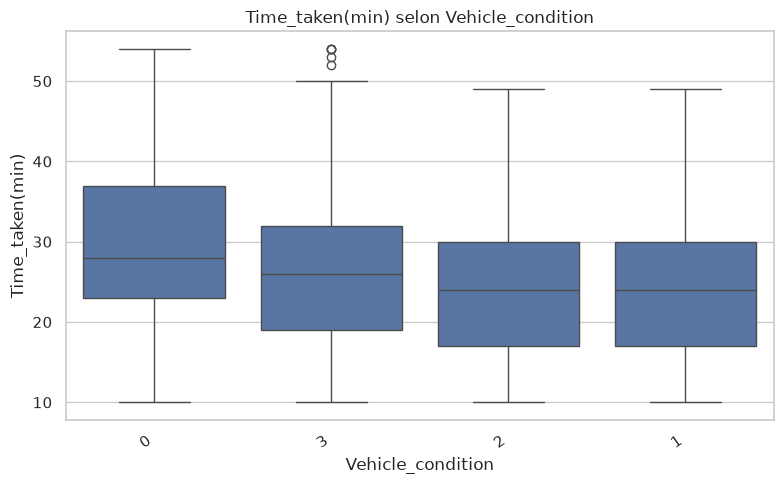


### Weatherconditions


,count,mean,median,std
Weatherconditions,,,,
Cloudy,6932,28.926,29.000,10.023
Fog,7581,28.777,28.000,10.098
Windy,6832,26.129,26.000,8.621
Stormy,6974,25.897,26.000,8.488
Sandstorms,6906,25.881,26.000,8.638
Sunny,6728,21.897,20.000,8.358


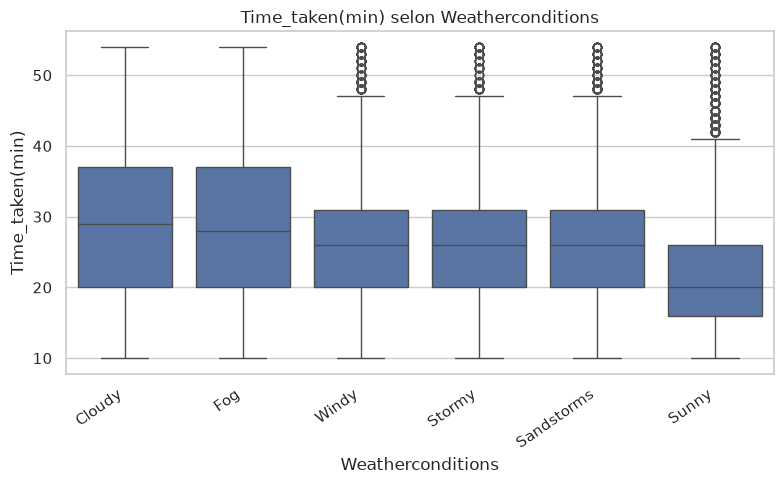


### Road_traffic_density


,count,mean,median,std
Road_traffic_density,,,,
Jam,13043,31.183,31.000,9.937
High,4071,27.226,27.000,8.416
Medium,10084,26.726,27.000,8.526
Low,14755,21.469,21.000,6.995


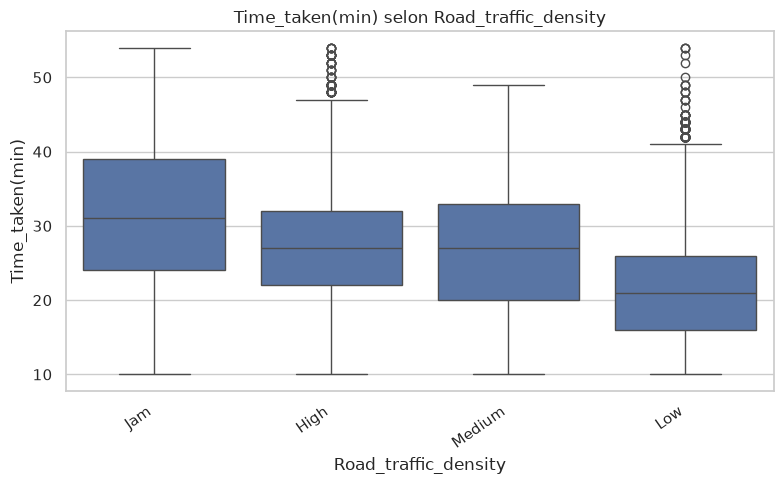


### Type_of_order


,count,mean,median,std
Type_of_order,,,,
Meal,10524,26.487,26.000,9.426
Snack,10616,26.324,26.000,9.418
Buffet,10368,26.240,25.500,9.386
Drinks,10445,26.194,25.000,9.290


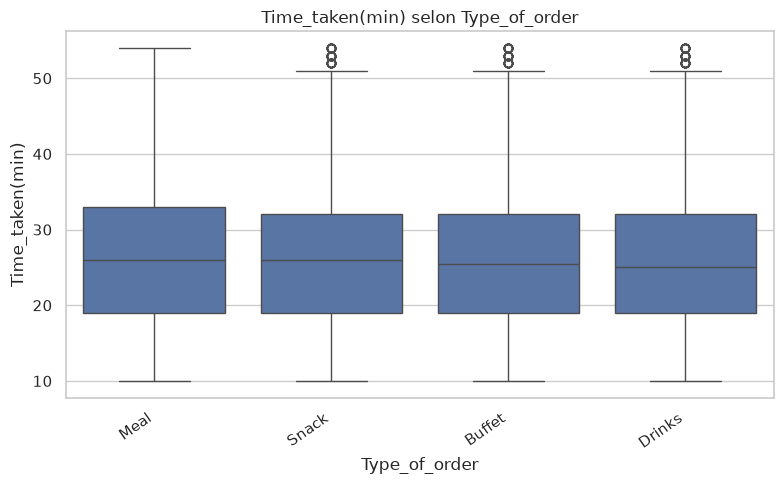


### Type_of_vehicle


,count,mean,median,std
Type_of_vehicle,,,,
motorcycle,24396,27.609,26.000,9.638
bicycle,60,26.417,26.500,8.960
scooter,14029,24.512,24.000,8.707
electric_scooter,3468,24.460,24.000,8.643


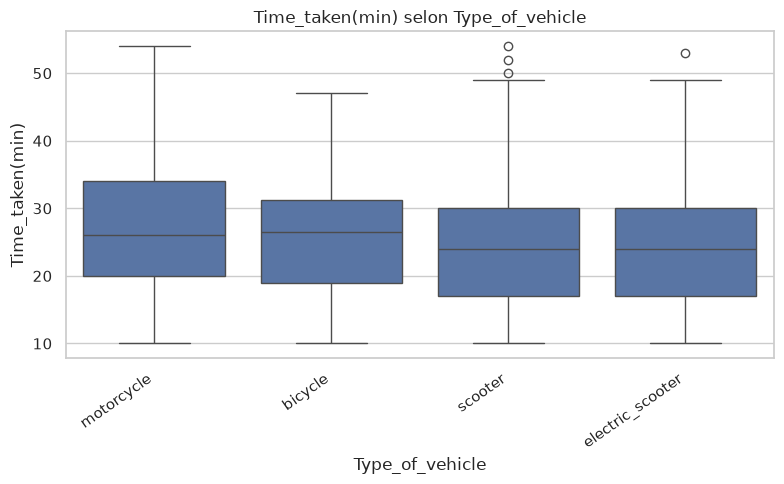


### Festival


,count,mean,median,std
Festival,,,,
Yes,822,45.479,45.000,4.017
No,41131,25.928,25.000,9.052


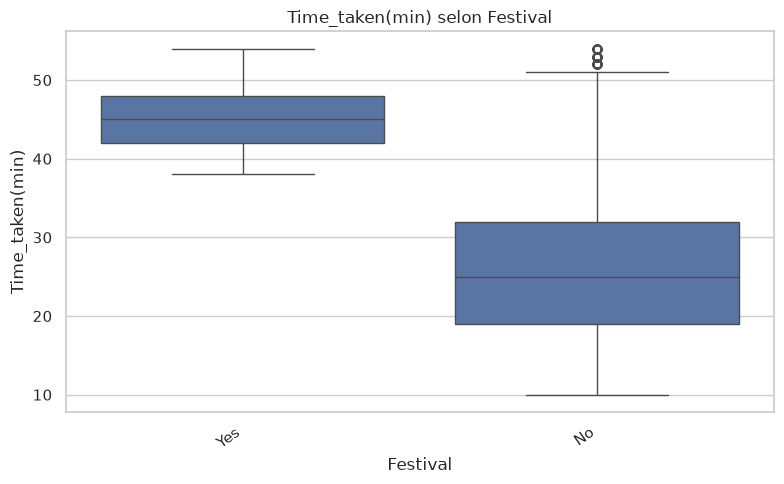


### City


,count,mean,median,std
City,,,,
Semi-Urban,149,49.678,49.000,2.732
Metropolitian,31411,27.321,27.000,9.186
Urban,9279,23.025,22.000,8.870
Unknown,1114,22.092,21.000,8.309


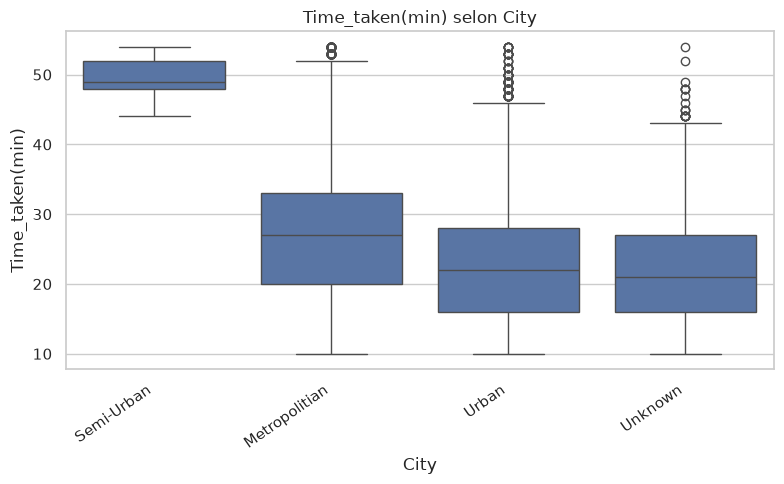

In [17]:
def eta_squared(data, category_column, target_column):
    valid = data[[category_column, target_column]].dropna()
    grand_mean = valid[target_column].mean()

    group_stats = (
        valid.groupby(category_column)[target_column]
        .agg(["count", "mean"])
    )

    between_ss = (
        group_stats["count"]
        * (group_stats["mean"] - grand_mean) ** 2
    ).sum()

    total_ss = (
        (valid[target_column] - grand_mean) ** 2
    ).sum()

    if total_ss == 0:
        return 0.0

    return between_ss / total_ss

categorical_relationships = []

for column in categorical_columns:
    categorical_relationships.append({
        "feature": column,
        "eta_squared": eta_squared(df, column, TARGET),
        "n_unique": df[column].nunique(dropna=False),
    })

categorical_relationships = (
    pd.DataFrame(categorical_relationships)
    .sort_values("eta_squared", ascending=False)
    .reset_index(drop=True)
)

display(categorical_relationships)

for column in categorical_columns:
    summary = (
        df.groupby(column, dropna=False)[TARGET]
        .agg(["count", "mean", "median", "std"])
        .sort_values("mean", ascending=False)
    )

    print(f"\n### {column}")
    display(summary)

    plt.figure(figsize=(8, 5))
    order = (
        df.groupby(column)[TARGET]
        .mean()
        .sort_values(ascending=False)
        .index
    )

    sns.boxplot(
        data=df,
        x=column,
        y=TARGET,
        order=order,
    )

    plt.title(f"{TARGET} selon {column}")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    save_fig(f"target_vs_{column}.png")
    plt.show()

## 9. Matrice de corrélation

La matrice de corrélation est construite uniquement sur les variables numériques.

Elle permet d'identifier :

- les variables numériquement liées à la cible ;
- les relations fortes entre variables explicatives ;
- les risques de redondance.

Une corrélation ne signifie pas causalité.

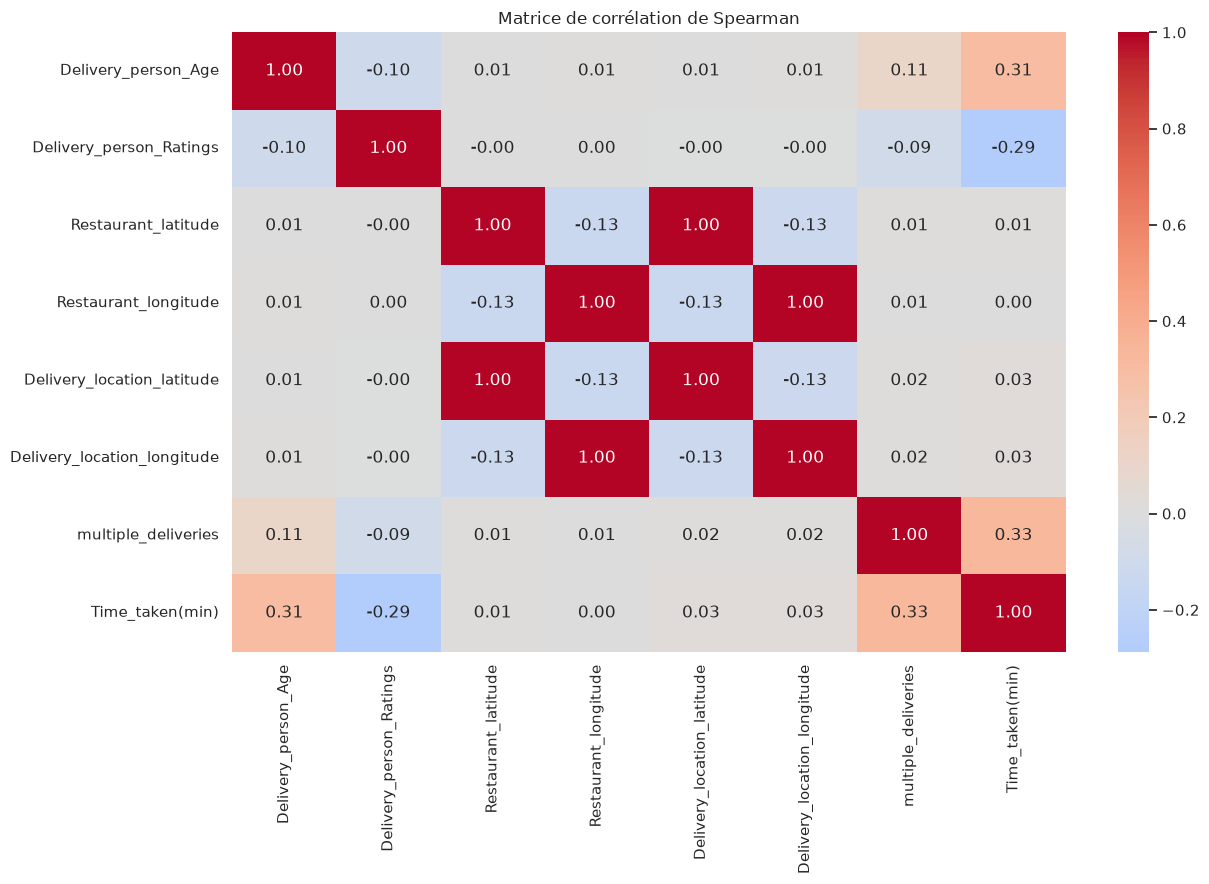

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,multiple_deliveries,Time_taken(min)
Delivery_person_Age,1.000,-0.102,0.006,0.010,0.006,0.010,0.109,0.309
Delivery_person_Ratings,-0.102,1.000,-0.000,0.003,-0.004,-0.002,-0.086,-0.287
Restaurant_latitude,0.006,-0.000,1.000,-0.132,0.997,-0.130,0.011,0.012
Restaurant_longitude,0.010,0.003,-0.132,1.000,-0.133,0.996,0.008,0.005
Delivery_location_latitude,0.006,-0.004,0.997,-0.133,1.000,-0.127,0.017,0.029
Delivery_location_longitude,0.010,-0.002,-0.130,0.996,-0.127,1.000,0.015,0.027
multiple_deliveries,0.109,-0.086,0.011,0.008,0.017,0.015,1.000,0.330
Time_taken(min),0.309,-0.287,0.012,0.005,0.029,0.027,0.330,1.000


In [18]:
correlation_matrix = df[numeric_columns].corr(method="spearman")

plt.figure(figsize=(13, 9))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
)
plt.title("Matrice de corrélation de Spearman")
plt.tight_layout()
save_fig("correlation_matrix_spearman.png")
plt.show()

display(correlation_matrix)

## 10. Variables les plus fortement liées au temps de livraison

Cette section synthétise les associations observées.

Pour les variables numériques, le classement utilise la valeur absolue de la corrélation de Spearman.

Pour les variables catégorielles, le classement utilise l'eta-squared.

**Attention :** ces scores servent à explorer les dépendances et à orienter le feature engineering. Ils ne déterminent pas à eux seuls quelles variables seront conservées dans le modèle final.

In [19]:
print("Top variables numériques selon |Spearman| :")
display(
    numeric_relationships[
        ["pearson", "spearman"]
    ].head(10)
)

print("\nTop variables catégorielles selon eta-squared :")
display(
    categorical_relationships.head(10)
)

Top variables numériques selon |Spearman| :


,pearson,spearman
multiple_deliveries,0.378,0.330
Delivery_person_Age,0.295,0.309
Delivery_person_Ratings,-0.335,-0.287
Delivery_location_latitude,0.014,0.029
Delivery_location_longitude,0.010,0.027
Restaurant_latitude,0.012,0.012
Restaurant_longitude,0.007,0.005



Top variables catégorielles selon eta-squared :


,feature,eta_squared,n_unique
0,Road_traffic_density,0.179,4
1,Festival,0.083,2
2,Vehicle_condition,0.080,4
3,City,0.063,4
4,Weatherconditions,0.062,6
5,Type_of_vehicle,0.027,4
6,Type_of_order,0.000,4


## 11. Remarque sur `Time_Orderd`

`Time_Orderd` ne contient plus de valeurs manquantes : elles ont été imputées en interne lors du nettoyage. Aucun indicateur de valeur imputée n'est conservé pour la modélisation — cette décision a été prise pour ne pas complexifier inutilement le jeu de variables final.

,count,mean,median,std
Order_Time_Missing,,,,
False,41953,26.312,26.000,9.381


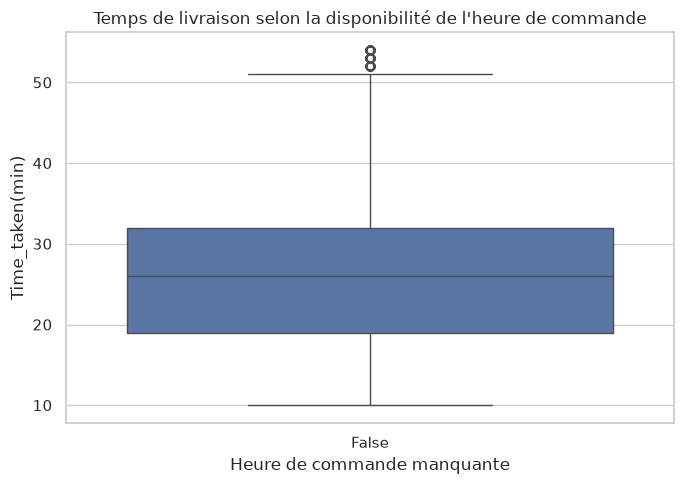

In [20]:
eda_time["Order_Time_Missing"] = eda_time["Time_Orderd"].isna()

missing_time_summary = (
    eda_time.groupby("Order_Time_Missing")[TARGET]
    .agg(["count", "mean", "median", "std"])
)

display(missing_time_summary)

plt.figure(figsize=(7, 5))
sns.boxplot(
    data=eda_time,
    x="Order_Time_Missing",
    y=TARGET,
)
plt.title("Temps de livraison selon la disponibilité de l'heure de commande")
plt.xlabel("Heure de commande manquante")
plt.ylabel(TARGET)
plt.tight_layout()
save_fig("target_vs_order_time_missing.png")
plt.show()

## 12. Conclusions de l'EDA

L'analyse exploratoire a permis de mieux comprendre la structure du jeu de données nettoyé et les principaux facteurs associés au temps total de livraison `Time_taken(min)`.

### 12.1 Qualité et structure des données

Le jeu de données utilisé pour l'EDA contient 41 953 observations et 18 variables. Seuls les identifiants (`ID`, `Delivery_person_ID`) ont été supprimés lors du nettoyage.

`Vehicle_condition` et `Time_Order_picked` sont conservées telles quelles. Aucune variable dérivée n'est créée par le nettoyage : ni temps de préparation, ni indicateur d'imputation. Ces éléments, s'ils s'avèrent utiles, seront construits dans le notebook de feature engineering.

Les contrôles effectués confirment :

- l'absence de doublons complets ;
- l'absence de valeurs manquantes, y compris pour `Time_Orderd` (imputée en interne lors du nettoyage) ;
- l'absence de coordonnées GPS négatives ou égales à (0, 0) ;
- l'absence de notes supérieures à 5 ;
- l'absence de valeurs manquantes dans la variable cible.

Le jeu de données ne contient donc plus aucune valeur manquante à ce stade.

---

### 12.2 Distribution de la variable cible

Le temps de livraison `Time_taken(min)` varie entre **10 et 54 minutes**.

La moyenne est de **26,31 minutes**, tandis que la médiane est de **26 minutes**, avec un écart-type de **9,38 minutes**. Les 50 % centraux des observations se situent entre **19 et 32 minutes**.

La distribution présente donc une dispersion relativement importante autour de la valeur centrale. Certaines livraisons sont nettement plus longues que la majorité, mais ces observations ne sont pas considérées comme automatiquement invalides : elles peuvent correspondre à des situations réelles de livraison difficiles.

Aucune suppression automatique des valeurs atypiques de la cible n'est donc justifiée à ce stade.

### 12.3 Variables numériques

L'analyse des corrélations montre que les coordonnées GPS prises individuellement présentent une association très faible avec `Time_taken(min)` :

* `Restaurant_latitude` : Spearman = **0,012** ;
* `Restaurant_longitude` : Spearman = **0,005** ;
* `Delivery_location_latitude` : Spearman = **0,029** ;
* `Delivery_location_longitude` : Spearman = **0,027**.

Ces faibles corrélations ne signifient cependant pas que les coordonnées sont inutiles. Une latitude ou une longitude isolée ne représente pas directement la distance parcourue. Les quatre coordonnées seront donc conservées afin de construire une variable plus pertinente, notamment une **distance restaurant-client (`Distance_km`)** lors du feature engineering.

Parmi les variables numériques, les associations les plus importantes avec le temps de livraison sont :

* `multiple_deliveries` : Spearman = **0,330** ;
* `Delivery_person_Age` : Spearman = **0,309** ;
* `Delivery_person_Ratings` : Spearman = **-0,287**.

Ces résultats indiquent notamment qu'une augmentation du nombre de livraisons multiples est associée à une augmentation du temps de livraison observé dans ce jeu de données. La relation observée avec l'âge du livreur est également positive, tandis que celle avec la note du livreur est négative.

Ces corrélations décrivent des associations statistiques et ne permettent pas de conclure à une relation causale.

### 12.4 Variables catégorielles

L'analyse par groupes montre des différences importantes entre certaines catégories.

La variable `Road_traffic_density` présente la plus forte association catégorielle avec la cible, avec un **eta-squared de 0,179**. Les temps moyens observés sont notamment :

* `Low` : **21,47 min** ;
* `Medium` : **26,73 min** ;
* `High` : **27,23 min** ;
* `Jam` : **31,18 min**.

La circulation apparaît donc comme une dimension importante de l'analyse du temps de livraison.

`Festival` présente également une association notable avec la cible (**eta-squared = 0,083**) :

* `No` : **25,93 min** en moyenne ;
* `Yes` : **45,48 min** en moyenne.

Cependant, la catégorie `Yes` ne représente que **1,96 %** des observations. Cette forte différence doit donc être interprétée en tenant compte de la faible fréquence de cette modalité.

`City` présente une association de **0,063**, avec des temps moyens différents selon les catégories. La catégorie `Semi-Urban` possède notamment une moyenne élevée (**49,68 min**), mais elle ne représente que **0,36 %** des observations. Ce faible effectif doit être pris en compte lors de l'interprétation et de la modélisation.

`Weatherconditions` présente également une association avec la cible (**eta-squared = 0,062**). Les temps moyens varient notamment entre **21,90 minutes pour Sunny** et **28,93 minutes pour Cloudy**.

`Type_of_vehicle` présente une association plus faible (**eta-squared = 0,027**), tandis que `Type_of_order` présente une association pratiquement nulle (**eta-squared ≈ 0**).

`Vehicle_condition` est désormais incluse dans l'analyse catégorielle. Son eta-squared avec `Time_taken(min)` est de **0.080**, à comparer aux associations déjà connues (`Road_traffic_density` : 0,179 ; `Festival` : 0,083 ; `City` : 0,063 ; `Weatherconditions` : 0,062 ; `Type_of_vehicle` : 0,027).

Comme pour les autres variables, une association catégorielle faible ou forte ne préjuge pas de son utilité finale dans un modèle capable de capter des interactions.

Ces résultats ne justifient pas à eux seuls la suppression de variables. Les variables seront conservées ou transformées puis leur contribution sera évaluée dans les modèles.

### 12.5 Analyse temporelle

L'analyse de `Time_Orderd` montre des différences entre les heures de commande.

Les temps moyens sont particulièrement élevés autour de **12 h à 14 h**, avec environ **30,8 à 31,2 minutes**, tandis que certaines périodes présentent des moyennes plus faibles, par exemple autour de **1 h à 3 h**, avec environ **19,5 à 19,7 minutes**.

L'analyse par jour de la semaine montre également des différences, avec une moyenne allant approximativement de **25,28 minutes le jeudi** à **27,76 minutes le mercredi**.

Les différences mensuelles sont beaucoup plus faibles :

* février : **26,52 min** ;
* mars : **26,31 min** ;
* avril : **26,14 min**.

Le mois semble donc présenter une variation plus limitée que l'heure ou le jour de la semaine dans ce jeu de données.

Ces résultats justifient la transformation de `Order_Date` et `Time_Orderd` en variables temporelles telles que :

* `Order_Hour` ;
* `Order_DayOfWeek` ;
* `Order_Month` ;
* `Is_Weekend`.

La variable `Time_Orderd` brute ne sera pas directement utilisée comme variable numérique dans les modèles.

### 12.6 Traitement de `Time_Orderd`

`Time_Orderd` ne contient plus de valeurs manquantes après le nettoyage. Aucun indicateur d'imputation n'est conservé : ce choix a été fait pour garder un jeu de variables minimal, l'information n'étant pas jugée indispensable à la modélisation.

`Order_Hour` sera extraite de `Time_Orderd` dans le notebook de feature engineering, sans qu'il soit nécessaire de gérer une valeur manquante à ce stade.

### 12.7 Redondance entre les coordonnées GPS

La matrice de corrélation montre une très forte corrélation entre certaines coordonnées :

* `Restaurant_latitude` et `Delivery_location_latitude` : **0,997** ;
* `Restaurant_longitude` et `Delivery_location_longitude` : **0,996**.

Cette forte corrélation est cohérente avec la structure géographique du jeu de données : les positions du restaurant et du client sont souvent proches et évoluent de manière similaire.

Cependant, supprimer arbitrairement une coordonnée à ce stade ferait perdre une partie de l'information géographique nécessaire au calcul de la distance.

Les quatre coordonnées seront donc conservées pour le feature engineer  ing, où elles serviront notamment à calculer la distance entre le restaurant et le lieu de livraison.

### 12.8 Variables retenues pour le feature engineering

Le feature engineering (notebook séparé) créera les variables suivantes :

- les quatre coordonnées GPS → `Distance_km` (formule de Haversine) ;
- `Order_Date` → `Order_Day`, `Order_DayOfWeek`, `Order_Month`, `Is_Weekend` ;
- `Time_Orderd` → `Order_Hour` ;
- `Time_Order_picked` → `Pickup_Hour` ;
- `Time_Order_picked - Time_Orderd` → `Preparation_Time_min`.

Une fois ces variables dérivées créées, les colonnes brutes suivantes seront supprimées : les quatre coordonnées GPS, `Order_Date`, `Time_Orderd` et `Time_Order_picked`.

Seules les variables issues du feature engineering seront conservées pour la modélisation, aux côtés de `Vehicle_condition`, déjà exploitable telle quelle depuis le nettoyage.

### 12.9 Conclusion générale

Outre les facteurs déjà identifiés (conditions de circulation, nombre de livraisons multiples, caractéristiques du livreur, météo, contexte géographique, période de commande, festival), une nouvelle dimension est disponible dès à présent : l'état du véhicule (`Vehicle_condition`).

Le temps de préparation de la commande (`Preparation_Time_min`) n'existe pas encore à ce stade : il sera calculé dans le notebook de feature engineering, à partir de `Time_Order_picked - Time_Orderd`. Son usage devra rester cohérent avec le périmètre métier retenu, puisqu'il suppose une prédiction faite à la prise en charge de la commande plutôt qu'au moment où elle est passée — un point à documenter explicitement lors de la modélisation et du déploiement.